# [Analysis of Crash Data Across New York City]
## CMSC 320 — Introduction to Data Science | Summer 2026

---

### Contributions

| Member | Sections | Summary |
|--------|----------|---------|
| Nipun Maisheri | A, B | Wrote the Introduction section (research questions, motivation, approach), and the Data Curation section detailing the dataset source, size, and preprocessing scope. |
| Ashhal Vohra | C, D, E | Ran the hypothesis tests and set up the Random Forest ML technique. Trained and evaluated the Random Forest model on the test set.|
| Arlan Baldomero | F | Created the feature importance bar chart. Provided the explanation of results and insights that go along with each plot. |
|  Jadah Malloy  | F, G, H | Helped with visualization creation, final result analysis and conclusion. Also created final tutorial and polished throughout the notebook. |

**Section Key:**
- A: Project idea  
- B: Dataset Curation and Preprocessing  
- C: Data Exploration and Summary Statistics  
- D: ML Algorithm Design/Development  
- E: ML Algorithm Training and Test Data Analysis  
- F: Visualization, Result Analysis, Conclusion  
- G: Final Tutorial Report Creation  
- H: Additional (not listed above)

---
## 1. Introduction

This project analyzes the [NYC Motor Vehicle Collisions — Crashes dataset](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95), a public record of over 2.2 million police-reported crashes across New York City maintained by the NYPD via NYC Open Data. Each row documents a single crash, including its date and time, borough, involved vehicle types, contributing factors, and the number of people injured or killed. Motor vehicle collisions are one of the leading causes of preventable injury and death in urban areas, and NYC's scale and data-collection history make it a rich case study for understanding when, where, and why crashes turn severe.

Our central research question is: **can we predict whether a crash will be fatal, and what factors most strongly drive that risk?** We break this down into three supporting questions explored through hypothesis testing in Checkpoint 2 and carried forward here: (1) Is a crash's fatality outcome associated with the type of vehicle involved? (2) Do crashes during rush hour differ in average injury severity from crashes at other times of day? (3) Are crashes at the city's highest-accident intersections more likely to be fatal than crashes elsewhere? We then build on these findings with a machine learning model that predicts fatal crashes directly from crash-time features.

These questions matter because the answers have direct, actionable value: city planners and the NYPD can use insight into high-risk vehicle types, times, and locations to target enforcement, infrastructure changes, or public-safety campaigns; insurers can better understand risk factors; and drivers and cyclists can be more informed about when and where collisions are most dangerous. Understanding fatality risk is more urgent than understanding crash frequency alone, since resources for preventing deaths are limited and should be directed where they have the greatest impact.

Our approach proceeds in three stages. First, we clean and preprocess the raw NYC Open Data export (2.2M+ rows, 37 columns), standardizing types and deriving fields such as crash hour and a binary fatal-crash indicator. Second, we perform exploratory data analysis using statistical hypothesis tests (chi-square, t-test, and Mann-Whitney U) to test the three questions above. Third, we frame fatal-crash prediction as a binary classification problem and train a Random Forest model, evaluating it with a confusion matrix, feature importances, and an ROC curve to identify which factors most influence crash fatality.

---
## 2. Data Curation

The data comes from the [NYC Motor Vehicle Collisions — Crashes dataset](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95) published by the New York City Police Department (NYPD) via NYC OpenData. The dataset records every police-reported motor vehicle collision in NYC. Each row represents a single crash event and includes information such as crash date and time, borough, street location, number of persons injured/killed, contributing factors, and vehicle types involved.

The raw export is retrieved directly from the NYC Open Data Socrata API as a JSON file (`rows.json`, roughly 1 GB), rather than committed to this repository, since it far exceeds GitHub's 100 MB file-size limit. The dataset covers every reported collision from July 2012 to the present, with new crashes added continuously so our pipeline downloads the current snapshot at run time, so the exact row count grows slightly with each run. At the time we developed this analysis, the snapshot contained approximately 2.27 million rows across 37 columns (after dropping 8 Socrata bookkeeping columns, 33 usable columns remain). A small minority of crashes in the dataset resulted in at least one fatality (the exact rate is computed in the preprocessing cell below), reflecting the substantial class imbalance we account for later in the modeling stage. 

In [ ]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os
import json
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")

# ── Load ───────────────────────────────────────────────────────────────────────
# The raw file is ~1 GB — too large to commit to GitHub (100 MB limit). Instead,
# we download it directly from the NYC Open Data API the first time this runs
# and cache it locally as rows.json (gitignored). Later runs reuse the cache.
DATA_URL = "https://data.cityofnewyork.us/api/views/h9gi-nx95/rows.json?accessType=DOWNLOAD"
PATH = "rows.json"

if not os.path.exists(PATH):
    print("rows.json not found locally — downloading from NYC Open Data (~1 GB, this may take a few minutes)...")
    urllib.request.urlretrieve(DATA_URL, PATH)
    print("Download complete.")
else:
    print("Using cached rows.json.")

with open(PATH) as f:
    raw = json.load(f)

columns = [c["fieldName"] for c in raw["meta"]["view"]["columns"]]
df = pd.DataFrame(raw["data"], columns=columns)
del raw

print(f"Raw shape: {df.shape}")
df.head(3)

Using cached rows.json.
Raw shape: (2269187, 37)


,:sid,:id,:position,:created_at,:created_meta,:updated_at,:updated_meta,:meta,crash_date,crash_time,...,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,collision_id,vehicle_type_code1,vehicle_type_code2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5
0,row-rsc3.wgwr-zpi9,00000000-0000-0000-2EDA-D04CF4F72CCD,0,1631659942,None,1631659946,None,{ },2021-09-11T00:00:00,2:39,...,Unspecified,None,None,None,4455765,Sedan,Sedan,None,None,None
1,row-t9dc~q8a7~jwk4,00000000-0000-0000-504A-3882B5C655F7,0,1648594368,None,1648594369,None,{ },2022-03-26T00:00:00,11:45,...,None,None,None,None,4513547,Sedan,None,None,None,None
2,row-h8ny_qxbv_ezwp,00000000-0000-0000-FFEC-C2F092D6EF34,0,1699314730,None,1699314738,None,{ },2023-11-01T00:00:00,1:29,...,Unspecified,Unspecified,None,None,4675373,Moped,Sedan,Sedan,None,None


In [2]:
# ── Preprocessing (carried over from Checkpoint 2) ────────────────────────────
# Drop Socrata bookkeeping columns
df = df.drop(columns=[c for c in df.columns if c.startswith(":")])

# Standardize string values. select_dtypes(include="object") can include columns
# that are all-null (and therefore inferred as float, not string), so we only
# apply .str methods to columns pandas actually recognizes as string-typed.
text_cols = [
    c for c in df.select_dtypes(include="object").columns
    if pd.api.types.infer_dtype(df[c], skipna=True) == "string"
]
df[text_cols] = df[text_cols].apply(lambda col: col.str.strip().str.upper())

# Numeric conversions
for col in ["number_of_persons_injured", "number_of_persons_killed",
            "number_of_pedestrians_injured", "number_of_pedestrians_killed",
            "number_of_cyclist_injured", "number_of_cyclist_killed",
            "number_of_motorist_injured", "number_of_motorist_killed",
            "latitude", "longitude", "zip_code"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Datetime
df["crash_date"] = pd.to_datetime(df["crash_date"], errors="coerce")
df["hour"] = pd.to_datetime(df["crash_time"], format="%H:%M", errors="coerce").dt.hour

# Derived target variable
df["fatal_crash"] = (df["number_of_persons_killed"] > 0).astype(int)

print(f"Clean shape: {df.shape}")
print(f"Fatal crashes: {df['fatal_crash'].sum()} ({df['fatal_crash'].mean():.2%})")

Clean shape: (2269187, 31)
Fatal crashes: 3469 (0.15%)


---
## 3. Exploratory Data Analysis

We present three conclusions drawn from the data using statistical hypothesis testing, carried
forward from Checkpoint 2:

1. Is fatal crash status independent of the vehicle type involved?
2. Does the mean number of injuries per crash during rush hour differ significantly from non-rush-hour crashes?
3. Is there a difference in the number of persons killed at the city's highest-accident intersections compared to other intersections?

### 3.1 Hypothesis 1 — Vehicle Type and Fatal Crash Risk

We test whether fatal crash status is independent of the primary vehicle type involved. To make
the comparison more reliable, we only include common vehicle types with at least 1,000 crashes.

**H0:** Fatal crash status is independent of vehicle type.
**H1:** Fatal crash status is associated with vehicle type.

We use a **chi-square test of independence** because both variables are categorical: vehicle type
and whether the crash involved at least one death.

In [3]:
from scipy.stats import chi2_contingency
import pandas as pd
import matplotlib.pyplot as plt

vehicle_cols = [
    "vehicle_type_code1",
    "vehicle_type_code2",
    "vehicle_type_code_3",
    "vehicle_type_code_4",
    "vehicle_type_code_5"
]

# Make sure fatal_crash exists
df["fatal_crash"] = df["number_of_persons_killed"] > 0

# Keep crash ID, fatal status, and vehicle columns
vehicle_involved_df = df[["collision_id", "fatal_crash"] + vehicle_cols].copy()

# Reshape so each involved vehicle gets its own row
vehicle_long = vehicle_involved_df.melt(
    id_vars=["collision_id", "fatal_crash"],
    value_vars=vehicle_cols,
    var_name="vehicle_position",
    value_name="vehicle_type"
)

# Clean vehicle type values
vehicle_long = vehicle_long.dropna(subset=["vehicle_type"])
vehicle_long["vehicle_type"] = vehicle_long["vehicle_type"].str.title().str.strip()

vehicle_long.head()

# Keep only common vehicle types
vehicle_counts = vehicle_long["vehicle_type"].value_counts()
common_vehicle_types = vehicle_counts[vehicle_counts >= 1000].index

vehicle_long_common = vehicle_long[
    vehicle_long["vehicle_type"].isin(common_vehicle_types)
].copy()

# Contingency table
fatal_table = pd.crosstab(
    vehicle_long_common["vehicle_type"],
    vehicle_long_common["fatal_crash"]
)

fatal_table.columns = ["Non-fatal crash", "Fatal crash"]

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(fatal_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 7253.812905760401
p-value: 0.0
Degrees of freedom: 39


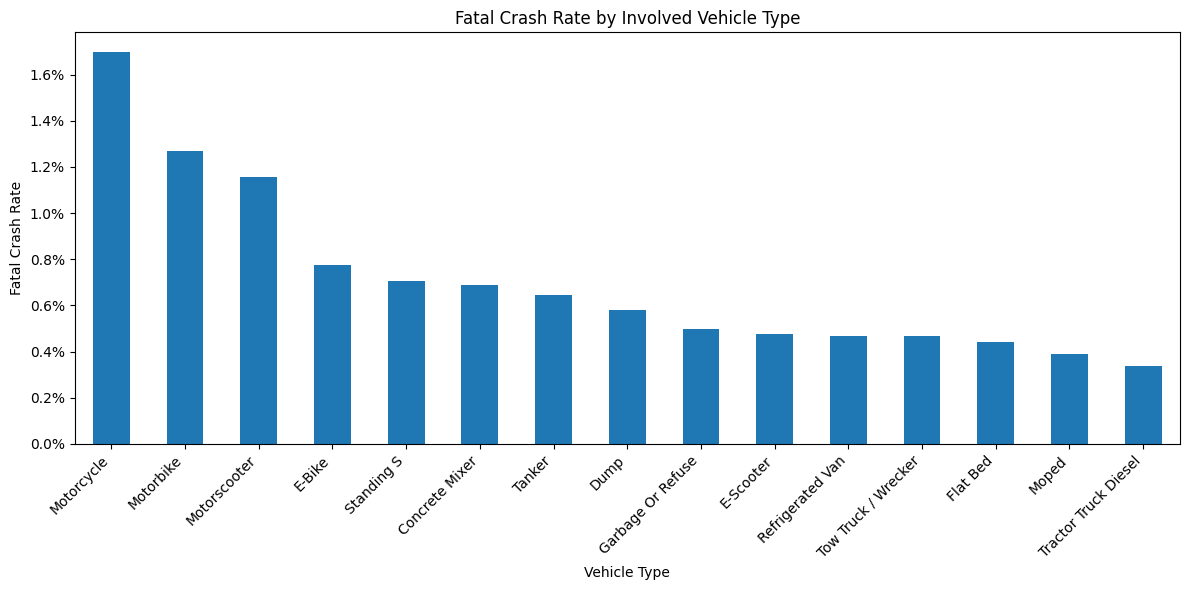

In [4]:
fatal_rates = (
    vehicle_long_common.groupby("vehicle_type")["fatal_crash"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
fatal_rates.plot(kind="bar")

plt.title("Fatal Crash Rate by Involved Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Fatal Crash Rate")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The chi-square test produced a chi-square statistic of 7253.81 with 39 degrees of freedom. The
p-value was reported as 0.0, which means it is extremely small, not literally zero. Since this
p-value is less than the significance level of 0.05, we reject the null hypothesis.

This suggests that fatal crash status is not independent of involved vehicle type. In other
words, the fatal crash rate differs across vehicle types in this dataset.

The plot shows that motorcycles, motorbikes, and motorscooters had some of the highest fatal
crash involvement rates among the common vehicle types. Motorcycle had the highest fatal crash
rate in this analysis, at about 1.7%. Other vehicle types such as E-Bike, Tanker, Dump, and
E-Scooter also appeared among the higher-risk groups.

However, this result does not prove that vehicle type directly causes fatal crashes. Vehicle
type may be related to other factors such as speed, road location, crash type, driver behavior,
exposure, or whether the person is protected inside a vehicle. Therefore, this analysis should
be interpreted as an association between vehicle type involvement and fatal crash status, not
as proof of causation.

### 3.2 Hypothesis 2 — Rush Hour vs. Non-Rush-Hour Injuries

We test whether the mean number of injuries per crash during rush hours (7–10 AM and 3–6 PM) is
significantly different from the mean number of injuries during non-rush-hour crashes.

**H0:** The mean number of persons injured per crash is the same during rush hour and non-rush hour.
**H1:** The mean number of persons injured per crash is different between rush hour and non-rush hour.

We use an **independent-samples t-test** since we are comparing the means of a continuous
variable (injuries per crash) between rush-hour crashes and non-rush-hour crashes.

In [5]:
rush_am = df[df["hour"].between(7, 10)]["number_of_persons_injured"].dropna()
rush_pm = df[df["hour"].between(15, 18)]["number_of_persons_injured"].dropna()
nonrush = df[~df["hour"].between(7, 10) & ~df["hour"].between(15, 18)]["number_of_persons_injured"].dropna()

t_stat_am, p_value_am = ttest_ind(rush_am, nonrush, equal_var=True)
t_stat_pm, p_value_pm = ttest_ind(rush_pm, nonrush, equal_var=True)

print("AM Rush Hour")
print("Mean injuries :", round(rush_am.mean(), 3))
print("T-stats :", round(t_stat_am, 3))
print("p-value :", round(p_value_am, 3))
if p_value_am < 0.05:
    print("Result: Null Hypothesis does not stand")
else:
    print("Result: Null hypothesis stands.")

print()
print("PM Rush Hour")
print("Mean injuries :", round(rush_pm.mean(), 3))
print("T-stats :", round(t_stat_pm, 3))
print("p-value :", round(p_value_pm, 3))
if p_value_pm < 0.05:
    print("Result: Null Hypothesis does not stand")
else:
    print("Result: Null hypothesis stands.")

print()
print("Non-rush hour mean injuries:", nonrush.mean())

AM Rush Hour
Mean injuries : 0.284
T-stats : -52.202
p-value : 0.0
Result: Null Hypothesis does not stand

PM Rush Hour
Mean injuries : 0.331
T-stats : -17.555
p-value : 0.0
Result: Null Hypothesis does not stand

Non-rush hour mean injuries: 0.35121364979199743


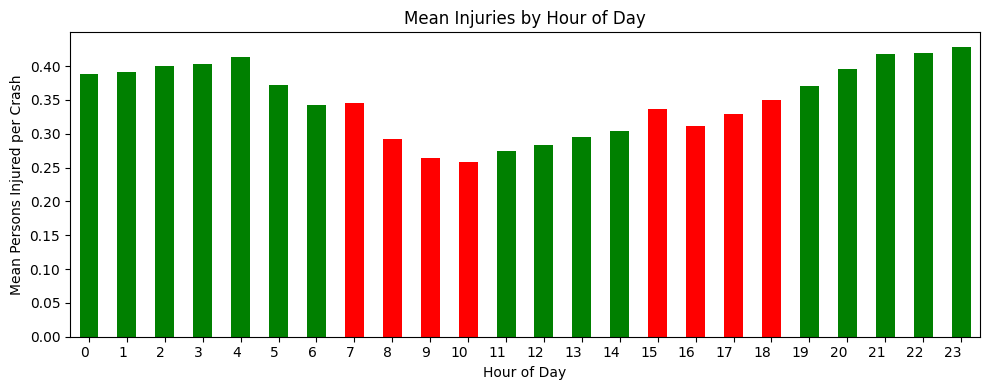

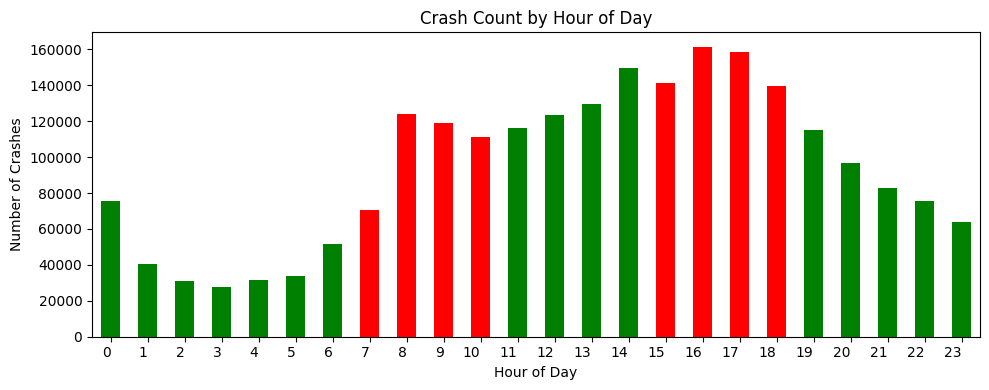

In [6]:
hourly_mean = df.groupby("hour")["number_of_persons_injured"].mean()

bar_colors = ["red" if (7 <= h <= 10 or 15 <= h <= 18) else "green" for h in hourly_mean.index]

plt.figure(figsize=(10, 4))
hourly_mean.plot(kind="bar", color=bar_colors)
plt.title("Mean Injuries by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Persons Injured per Crash")
plt.xticks(rotation=0, ha="right")
plt.tight_layout()
plt.show()

hourly_crashes = df.groupby("hour")["collision_id"].count()

bar_colors = ["red" if (7 <= h <= 10 or 15 <= h <= 18) else "green" for h in hourly_crashes.index]

plt.figure(figsize=(10, 4))
hourly_crashes.plot(kind="bar", color=bar_colors)
plt.title("Crash Count by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=0, ha="right")
plt.tight_layout()
plt.show()

The t-test produced a t-statistic of -52.20 for the morning rush hour (7–10 AM) and -17.56 for
the afternoon rush hour (3–6 PM). In both cases, the p-values were around 0.0, well below the
significance level of 0.05. Because of this, we reject the null hypothesis.

This means there is a statistically significant difference in the average number of injuries
per crash between rush hour and non-rush-hour times. In other words, crashes that happen during
rush hour do not have the same average injury rate as those that happen at non-rush-hour times
of day.

Looking at the graph, the average number of injuries per crash during the morning rush hour was
about 0.28, while the afternoon rush hour averaged around 0.33. Both of these values were lower
than the non-rush-hour average of 0.35 injuries per crash. Even though more crashes happen
during rush hour because there are more vehicles on the road, the crashes themselves are, on
average, *less* severe — the opposite of what we initially expected.

It is important to remember that these results only show a relationship, not a cause-and-effect
connection. Rush hour does not necessarily cause fewer injuries. Other factors, such as slower
traffic speeds due to congestion, increased driver awareness, different types of collisions, or
changing road conditions, could all contribute to the lower average number of injuries. Overall,
the analysis suggests that time of day does matter for crash severity.

### 3.3 Hypothesis 3 — High-Accident Intersections and Fatality Rates

We test whether the number of persons killed at a high-accident intersection is significantly
different from a non-high-accident intersection, comparing the top 5 intersections with the
most accidents against all other intersections.

**H0:** There is no significant difference in the number of people killed at top-5 high-accident
intersections compared to non-top-5 intersections.
**H1:** There is a significant difference in the number of people killed at top-5 high-accident
intersections compared to non-top-5 intersections.

We use the **Mann-Whitney U test** because the number of persons killed per crash is
non-normally distributed (mostly zeros with rare high values), and we want to compare ranks
rather than assume a normal distribution.

In [7]:
# Hypothesis 3: Top high-accident intersections vs non-top intersections

h3_df = df.copy()

# Clean street columns
h3_df["on_street_name"] = h3_df["on_street_name"].fillna("").astype(str).str.strip().str.lower()
h3_df["off_street_name"] = h3_df["off_street_name"].fillna("").astype(str).str.strip().str.lower()

# Keep only rows where both street names exist
h3_df = h3_df[
    (h3_df["on_street_name"] != "") &
    (h3_df["off_street_name"] != "")
].copy()

print("Rows after removing missing streets:", len(h3_df))

# Sort street pairs row-by-row so flipped intersections count together
street_pairs = np.sort(
    h3_df[["on_street_name", "off_street_name"]].values,
    axis=1
)

h3_df["street_1"] = street_pairs[:, 0]
h3_df["street_2"] = street_pairs[:, 1]

# Count crashes per intersection
intersections = (
    h3_df
    .groupby(["street_1", "street_2"])
    .size()
    .sort_values(ascending=False)
)

print("Number of unique intersections:", len(intersections))
print(intersections.head(10))

# Top 5 intersections with the most accidents
top_intersections = intersections.head(5).index

# Create tuple column
h3_df["top_intersections"] = list(zip(h3_df["street_1"], h3_df["street_2"]))

# Make sure deaths are numeric
h3_df["number_of_persons_killed"] = pd.to_numeric(
    h3_df["number_of_persons_killed"],
    errors="coerce"
).fillna(0)

# Get the persons killed from top intersections and non-top intersections
top_persons_killed = h3_df[
    h3_df["top_intersections"].isin(top_intersections)
]["number_of_persons_killed"]

diff_persons_killed = h3_df[
    ~h3_df["top_intersections"].isin(top_intersections)
]["number_of_persons_killed"]

print("Top sample size:", len(top_persons_killed))
print("Non-top sample size:", len(diff_persons_killed))

# Test difference using Mann-Whitney U
mwu_stat, p_value_man = mannwhitneyu(
    top_persons_killed,
    diff_persons_killed,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", round(mwu_stat, 3))
print("p-value:", round(p_value_man, 3))

if p_value_man < 0.05:
    print("Result: Rejected the Null Hypothesis.")
else:
    print("Result: Failed to reject the Null Hypothesis.")

Rows after removing missing streets: 1398677
Number of unique intersections: 82620
street_1                   street_2           
flatbush avenue extension  tillary street         1211
bruckner boulevard         east 138 street        1106
brookville boulevard       rockaway boulevard     1067
flatbush avenue            grand army plaza       1028
major deegan expressway    west fordham road       947
bruckner boulevard         hunts point avenue      908
atlantic avenue            pennsylvania avenue     882
2 avenue                   east 59 street          858
linden boulevard           pennsylvania avenue     804
queens boulevard           woodhaven boulevard     754
dtype: int64
Top sample size: 5359
Non-top sample size: 1393318
Mann-Whitney U statistic: 3734239193.5
p-value: 0.683
Result: Failed to reject the Null Hypothesis.


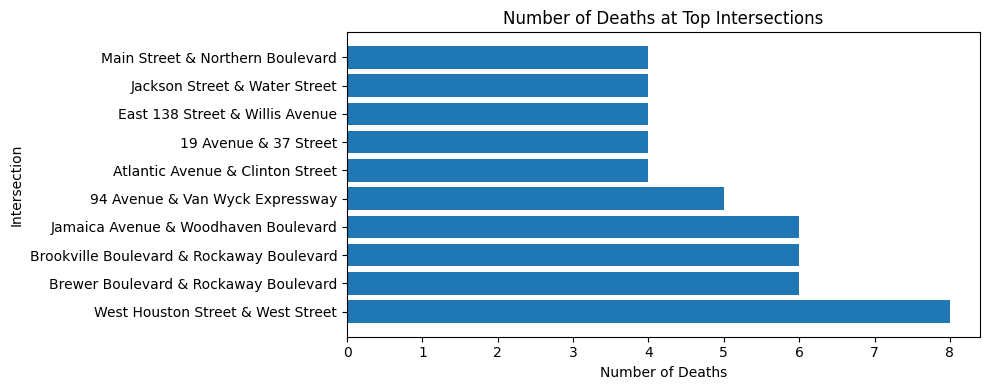

In [8]:
# Plot intersections with the most deaths

deaths = (
    h3_df
    .groupby(["street_1", "street_2"])["number_of_persons_killed"]
    .sum()
    .sort_values(ascending=False)
)

top_10_intersections = deaths.head(10)

street_names = [
    f"{s1.title()} & {s2.title()}"
    for s1, s2 in top_10_intersections.index
]

counts = top_10_intersections.to_numpy()

plt.figure(figsize=(10, 4))

plt.barh(street_names, counts)

plt.title("Number of Deaths at Top Intersections")
plt.xlabel("Number of Deaths")
plt.ylabel("Intersection")

plt.tight_layout()
plt.show()

The Mann-Whitney U test resulted in a p-value of 0.683. Since p ≥ 0.05, we fail to reject the
null hypothesis.

This means there is not enough statistical evidence to say that crashes at the top-5
high-accident intersections have a significantly different number of deaths compared to crashes
at non-top-5 intersections.

Even though some intersections have far more crashes overall, this does not necessarily mean
each crash at those intersections is more deadly. Most crashes have zero deaths, so the number
of deaths per crash stays very low in both groups. The plot shows the intersections with the
highest *total* number of deaths, which helps illustrate that fatal crashes are rare and
concentrated in a small number of intersections in absolute terms — but this doesn't translate
into a higher *per-crash* fatality rate at those specific locations.

---
## 4. Primary Analysis — Machine Learning

Our Data Analysis showed that vehicle type (Hypothesis 1) and time of day (Hypothesis 2) are both
significantly associated with crash outcomes, while intersection level crash frequency
(Hypothesis 3) is not. Our research question asks *whether* a crash will be fatal and
*which* factors drive that risk, so the regression doesn't fit a categorical target, and clustering wouldn't let us predict fatality
for a new crash or rank feature importance.

We chose Random Forest classification because it works well with both categorical and numerical data, captures complex relationships without requiring strong assumptions, and shows which features are most important in predicting fatal crashes.

In [9]:
# Feature selection
FEATURE_COLS = [
    "hour",
    "number_of_persons_injured",
    "number_of_pedestrians_injured",
    "number_of_cyclist_injured",
    "number_of_motorist_injured",
    "borough",
    "vehicle_type_code1",
    "contributing_factor_vehicle_1",
]
TARGET_COL = "fatal_crash"

ml_df = df[FEATURE_COLS + [TARGET_COL]].dropna()
print(f"ML dataset shape: {ml_df.shape}")
print(f"Class balance:\n{ml_df[TARGET_COL].value_counts(normalize=True)}")

ML dataset shape: (1562184, 9)
Class balance:
fatal_crash
False    0.998678
True     0.001322
Name: proportion, dtype: float64


In [10]:
# Converting text to numbers for Random Forest and keeping the top categories for
# each column.
cat_cols = ["borough", "vehicle_type_code1", "contributing_factor_vehicle_1"]

K = 20
for col in cat_cols:
    top_k = ml_df[col].value_counts().head(K).index
    ml_df[col] = ml_df[col].where(ml_df[col].isin(top_k), other="OTHER")

ml_encoded = pd.get_dummies(ml_df, columns=cat_cols, drop_first=True)

X = ml_encoded.drop(columns=[TARGET_COL])
y = ml_encoded[TARGET_COL]

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (1562184, 48)


In [11]:
# Train / test split (80/20)
seed = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=seed, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 1249747 rows | Test: 312437 rows


In [12]:
# Model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=seed,
    n_jobs=-1
)

In [13]:
# Cross-validation on the training set
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
cv_scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring="roc_auc")
print(f"CV ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

CV ROC-AUC: 0.781 (+/- 0.011)


In [14]:
# Train and evaluate test set
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.814
              precision    recall  f1-score   support

       False       1.00      0.81      0.90    312024
        True       0.00      0.58      0.01       413

    accuracy                           0.81    312437
   macro avg       0.50      0.70      0.45    312437
weighted avg       1.00      0.81      0.90    312437



The baseline model shows why accuracy is misleading for this problem. Since almost all crashes are non-fatal, a model can achieve high accuracy by predicting every crash as non-fatal, but that provides no useful fatal-crash detection. Logistic Regression gives a simpler comparison point, while Random Forest can capture non-linear relationships and interactions between crash features. Because the Random Forest had stronger ranking performance and provided feature importances, it was selected as the primary model.

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

models = {
    "Baseline: Most Frequent": DummyClassifier(strategy="most_frequent", random_state=seed),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, probs)
        pr_auc = average_precision_score(y_test, probs)
    else:
        roc = np.nan
        pr_auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Fatal Precision": precision_score(y_test, preds, zero_division=0),
        "Fatal Recall": recall_score(y_test, preds, zero_division=0),
        "Fatal F1": f1_score(y_test, preds, zero_division=0),
        "ROC-AUC": roc,
        "PR-AUC": pr_auc
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Fatal Precision,Fatal Recall,Fatal F1,ROC-AUC,PR-AUC
0,Baseline: Most Frequent,0.998678,0.000000,0.000000,0.000000,0.500000,0.001322
1,Logistic Regression,0.735876,0.003291,0.658596,0.006549,0.766975,0.009581
2,Random Forest,0.814283,0.004131,0.581114,0.008204,0.778211,0.014244


---
## 5. Visualization

**── Plot 1: Confusion Matrix ──────────────────────────────────────────────────**

The confusion matrix below illustrates how well our Random Forest (RF) classifier predicted `Fatal` and `Non-Fatal` crashes on the test dataset. The model correctly classified most Non-Fatal crashes as Non-Fatal, which means it performed well on the majority class. However, this is partly expected because almost all crashes in the dataset are Non-Fatal.

For Fatal crashes, the model performed much worse. It correctly identified about 58% of the actual Fatal crashes, meaning the Fatal recall was moderate. However, the precision for the Fatal class was extremely low, meaning that most crashes predicted as Fatal were actually Non-Fatal. In other words, the model catches some Fatal crashes, but it also produces many false positives.

This shows that the model still struggles with the Fatal-crash class, which is expected because Fatal crashes are extremely rare compared to Non-Fatal crashes. The model is not necessarily underfitted overall, but it has difficulty learning strong patterns from the small number of Fatal examples. We can see why this happens from the dataset's class distribution: about 99.8% of the samples are Non-Fatal, while only a tiny fraction are Fatal. This class imbalance makes it difficult for the Random Forest model to learn reliable decision rules for Fatal crashes.

The Random Forest (`rf`) model was already trained on `X_train` and `y_train` and evaluated on `X_test` and `y_test` in Section 4, so those variables are used directly below.

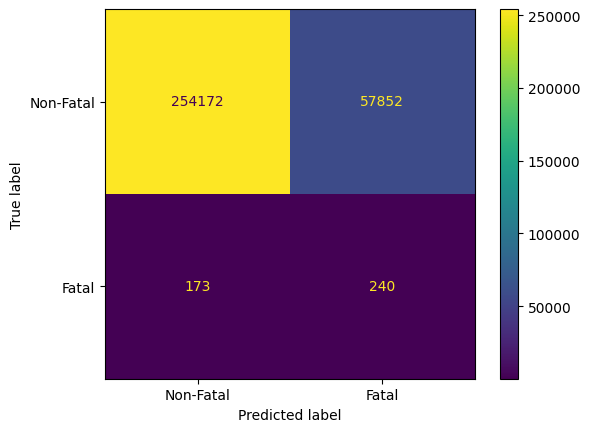

In [16]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, display_labels=["Non-Fatal", "Fatal"])

**── Plot 2: Feature Importances (Random Forest) ───────────────────────────────**

The bar chart below shows which features contributed most to the Random Forest model's predictions. In this model, feature importance measures how much each variable helped reduce impurity across the decision trees in the forest. Based on the results, time of day (`hour`) was one of the most important predictors, suggesting that crash timing contains useful information for distinguishing fatal and non-fatal crashes.

Vehicle type also mattered, especially motorcycles, which supports the earlier chi-square test showing that fatal crash status is associated with the types of vehicles involved. Several contributing factors, such as disregarding traffic control, unsafe driving behavior, and failure to yield the right of way, also appeared among the top features. These results suggest that fatality risk is related to a combination of timing, vehicle type, and crash circumstances rather than one single factor.

One important limitation is that injury-count variables are post-crash severity indicators rather than information available before a crash happens. This means the model is best interpreted as predicting fatality status within reported crash records, not as a fully pre-crash prevention model. A future version of the project could train a second model using only pre-crash/context features such as hour, borough, vehicle type, contributing factors, and location.

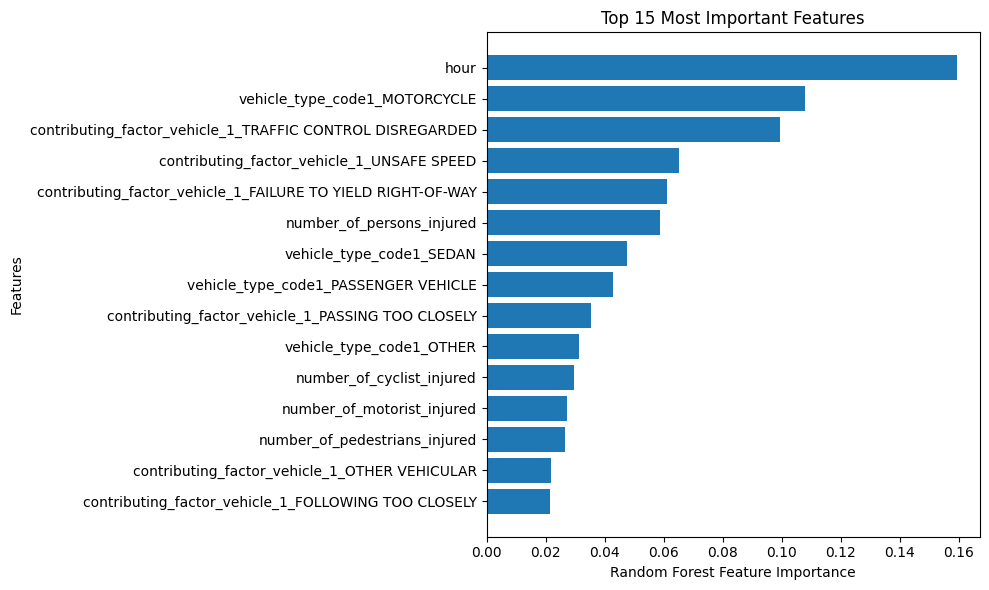

In [17]:
rf_df = pd.DataFrame({
    "Features": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.title("Top 15 Most Important Features")
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Features")

plt.barh(rf_df["Features"].tail(15), rf_df["Importance"].tail(15))

plt.tight_layout()
plt.show()

**── Plot 3: ROC curve ──────────────────────────────────────────────────**

The Receiver Operating Characteristic (ROC) curve shows how the model's true positive rate and false positive rate change as the classification threshold changes. The Area Under the Curve (AUC) was about 0.78, which means the model separates fatal crashes from non-fatal crashes better than random guessing. However, AUC is not the same thing as a classification threshold. Instead, it summarizes the model's overall ability to rank fatal crashes as higher risk than non-fatal crashes.

Since fatal crashes are rare and more important to detect, a future version of this model could adjust the classification threshold to increase recall for fatal crashes. This might create more false positives, but it could be useful in a traffic-safety setting where missing a high-risk crash pattern is more costly than flagging too many crashes.

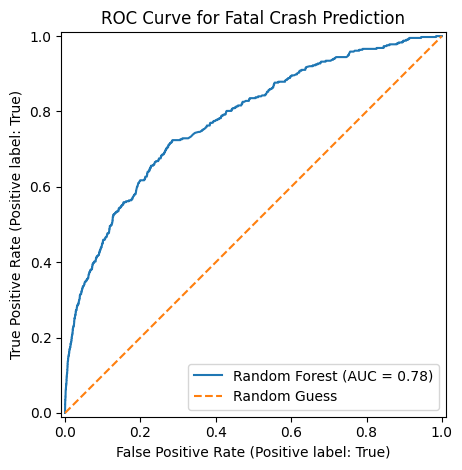

Test ROC-AUC: 0.778


In [18]:
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest")
y_proba = rf.predict_proba(X_test)[:, 1]
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.title("ROC Curve for Fatal Crash Prediction")
plt.legend()
plt.tight_layout()
plt.show()
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

The Precision-Recall curve is especially important because fatal crashes are the minority class. While the ROC curve measures how well the model separates fatal and non-fatal crashes overall, the Precision-Recall curve focuses more directly on the model's ability to identify fatal crashes without producing too many false positives. This is useful for a rare-event problem where the positive class is the main concern.

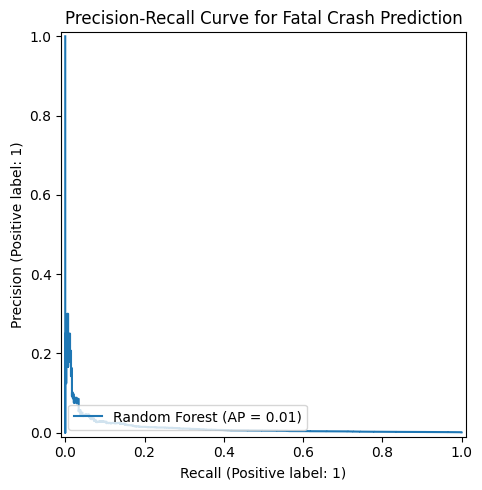

Average Precision: 0.0142


In [19]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

y_proba = rf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    name="Random Forest",
    ax=ax
)
plt.title("Precision-Recall Curve for Fatal Crash Prediction")
plt.tight_layout()
plt.show()

print("Average Precision:", round(average_precision_score(y_test, y_proba), 4))

Changing the threshold changes the balance between precision and recall. A lower threshold usually identifies more fatal crashes, increasing recall, but it also creates more false positives. In a traffic-safety setting, a lower threshold may be acceptable because missing a potentially fatal crash pattern is more serious than flagging too many crashes for review.

In [20]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

threshold_results = []

for t in thresholds:
    threshold_preds = (y_proba >= t).astype(int)
    threshold_results.append({
        "Threshold": t,
        "Fatal Precision": precision_score(y_test, threshold_preds, zero_division=0),
        "Fatal Recall": recall_score(y_test, threshold_preds, zero_division=0),
        "Fatal F1": f1_score(y_test, threshold_preds, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,Threshold,Fatal Precision,Fatal Recall,Fatal F1
0,0.1,0.001322,1.000000,0.002640
1,0.2,0.001343,0.997579,0.002681
2,0.3,0.001475,0.978208,0.002946
3,0.4,0.002072,0.876513,0.004134
4,0.5,0.004131,0.581114,0.008204


---
## 6. Insights and Conclusions


Overall, the Random Forest model showed that fatal crash risk can be predicted better than random guessing, but the problem is still difficult because fatal crashes are extremely rare compared to non-fatal crashes. The most important features in the model were mainly related to injury counts, time of day, borough, vehicle type, and contributing factors. This makes sense because crashes involving injuries or certain high-risk conditions are more likely to be connected to severe outcomes. The machine learning results also supported some of the EDA findings, especially the idea that vehicle type and time-related patterns matter for crash outcomes.

The model's accuracy may look strong at first, but accuracy is not the best metric for this project because the dataset is highly imbalanced. Since most crashes are non-fatal, a model can get high accuracy even if it misses many fatal crashes. For that reason, the confusion matrix, recall for the fatal class, and ROC-AUC are more useful than accuracy alone. The Random Forest used `class_weight="balanced"`, which helps the model pay more attention to the rare fatal-crash class, but the model still has limitations because there are so few fatal examples to learn from.

The results suggest that city planners and traffic-safety officials should focus less on crash count alone and more on crash severity. Some intersections or areas may have many crashes but not necessarily a higher fatality rate per crash. Instead, the model points toward a combination of factors, such as vehicle type, contributing cause, borough, time of day, and injury-related variables, as more useful for identifying higher-risk crashes. This could help guide targeted safety improvements, public-awareness campaigns, enforcement, or infrastructure changes in locations and situations where fatality risk is higher.

There are also important limitations. The dataset has missing values in several location, vehicle, and contributing-factor columns, and the model only uses a limited set of features. Some useful information, such as weather, lighting, road design, traffic speed, traffic volume, exact intersection geometry, and emergency-response time, is not included in the model. Also, because this is observational crash data, the model can show patterns and associations, but it cannot prove that a feature directly causes fatal crashes.

Another limitation is that some of the strongest predictors, especially injury-count variables, are known after the crash has already occurred. Because of this, the model should not be interpreted as a complete early-warning system for preventing crashes before they happen. Instead, it is more useful as a severity-analysis model that helps identify patterns in reported crashes. For prevention planning, a future model should be trained using only information available before or at the time of the crash, such as location, time of day, vehicle type, and contributing factors.

With more time, we would improve the project by adding spatial analysis with latitude and longitude, possibly using `geopandas` to map fatal-crash hot spots more precisely. we would also test other models, tune the Random Forest more carefully, compare different class-imbalance methods, and add outside data such as weather, speed limits, road type, and traffic volume. After reading this tutorial, a reader should understand the main problem, how the NYC crash data was cleaned and analyzed, what the model found, and why predicting fatal crashes is challenging but useful for real-world traffic safety.
